<style>
.jp-Notebook .jp-MarkdownCell,
.text_cell_render {
    font-size: 14px;
    line-height: 1.38;
}
.jp-CodeCell .cm-editor,
.jp-CodeCell pre,
.code_cell .CodeMirror {
    font-size: 13px !important;
    line-height: 1.30 !important;
}
</style>

# ECON 422: Macroeconomics & Machine Learning
## Double/Debiased Machine Learning

Consider the partially linear model

$$
\begin{aligned}
Y_i &= \theta_0D_i+g_0(X_i)+U_i,
& E[U_i\mid D_i,X_i]&=0,\\
D_i &= d_0(X_i)+V_i,
& E[V_i\mid X_i]&=0.
\end{aligned}
$$

DML estimates the two nuisance functions

$$
h_0(X)=E[Y\mid X],
\qquad
d_0(X)=E[D\mid X],
$$

using cross-fitting. It then relates the residualized outcome to the residualized treatment:

$$
\widetilde Y_i
=Y_i-\widehat h^{(-k)}(X_i),
\qquad
\widetilde D_i
=D_i-\widehat d^{(-k)}(X_i).
$$

The final estimator is

$$
\widehat\theta
=
\frac{\sum_i \widetilde D_i\widetilde Y_i}
{\sum_i \widetilde D_i^2}.
$$


### Practice 1 - Import the tools

We use random forests for the nuisance functions and `KFold` for cross-fitting.

Type the gray code in the cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold</pre>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

### Practice 2 - Generate nonlinear confounding

The treatment and outcome both depend nonlinearly on the controls. The target remains $\theta_0=2$.

Type the gray code in the cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">rng = np.random.default_rng(123)
n = 800
X = rng.normal(size=(n, 4))
theta_true = 2.0

d0 = 0.8*X[:, 0] - 0.5*X[:, 1]**2 + 0.7*np.sin(X[:, 2])
g0 = d0 + 0.7*X[:, 1]*X[:, 2] + 0.4*X[:, 3]**2

D = d0 + rng.normal(size=n)
Y = theta_true*D + g0 + rng.normal(size=n)

print("X shape:", X.shape)
print("True theta:", theta_true)</pre>


In [2]:
# Type the codes.
rng = np.random.default_rng(123)
n = 800
X = rng.normal(size=(n, 4))
theta_true = 2.0

d0 = 0.8*X[:, 0] - 0.5*X[:, 1]**2 + 0.7*np.sin(X[:, 2])
g0 = d0 + 0.7*X[:, 1]*X[:, 2] + 0.4*X[:, 3]**2

D = d0 + rng.normal(size=n)
Y = theta_true*D + g0 + rng.normal(size=n)

print("X shape", X.shape)
print("True theta:", theta_true)

X shape (800, 4)
True theta: 2.0


### Practice 3 - See the naive estimate

Regressing $Y$ only on $D$ ignores the common dependence on $X$.

Type the gray code in the cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">naive_model = LinearRegression().fit(D.reshape(-1, 1), Y)
theta_naive = naive_model.coef_[0]

print(f"Naive estimate: {theta_naive:.3f}")</pre>


In [3]:
# Type the codes.
naive_model = LinearRegression().fit(D.reshape(-1, 1), Y)
theta_naive = naive_model.coef_[0]

print(f"Naive estimate: {theta_naive:.3f}")

Naive estimate: 2.550


### Practice 4 - Cross-fit the nuisance functions

Each held-out row receives predictions from models trained on the other folds.

Type the gray code in the cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">h_hat = np.empty(n)
d_hat = np.empty(n)
kf = KFold(n_splits=5, shuffle=True, random_state=123)

def rf(seed):
    return RandomForestRegressor(
        n_estimators=200, min_samples_leaf=8,
        random_state=seed, n_jobs=-1
    )

for train_idx, test_idx in kf.split(X):
    y_model, d_model = rf(123), rf(456)
    y_model.fit(X[train_idx], Y[train_idx])
    d_model.fit(X[train_idx], D[train_idx])
    h_hat[test_idx] = y_model.predict(X[test_idx])
    d_hat[test_idx] = d_model.predict(X[test_idx])</pre>


In [4]:
# Type the codes.
h_hat = np.empty(n)
d_hat = np.empty(n)
kf = KFold(n_splits=5, shuffle=True, random_state=123)

def rf(seed):
    return RandomForestRegressor(
        n_estimators=200, min_samples_leaf=8,
        random_state=seed, n_jobs=-1
    )

for train_idx, test_idx in kf.split(X):
    y_model, d_model = rf(123), rf(456)
    y_model.fit(X[train_idx], Y[train_idx])
    d_model.fit(X[train_idx], D[train_idx])
    h_hat[test_idx] = y_model.predict(X[test_idx])
    d_hat[test_idx] = d_model.predict(X[test_idx])

### Practice 5 - Residualize and estimate DML

Use the pooled out-of-fold residuals in the residual-on-residual regression.

Type the gray code in the cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">Y_tilde = Y - h_hat
D_tilde = D - d_hat

theta_dml = np.sum(D_tilde * Y_tilde) / np.sum(D_tilde**2)

comparison = pd.DataFrame({
    "Quantity": ["True theta", "Naive estimate", "DML estimate"],
    "Value": [theta_true, theta_naive, theta_dml]
})
print(comparison.to_string(index=False, formatters={"Value": "{:.3f}".format}))</pre>


In [5]:
# Type the codes.
Y_tilde = Y - h_hat
D_tilde = D - d_hat

theta_dml = np.sum(D_tilde * Y_tilde) / np.sum(D_tilde**2)

comparison = pd.DataFrame({
    "Quantity": ["True theta", "Naive estimate", "DML estimate"],
    "Value": [theta_true, theta_naive, theta_dml]
})
print(comparison.to_string(index=False, formatters={"Value": "{:.3f}".format}))

      Quantity Value
    True theta 2.000
Naive estimate 2.550
  DML estimate 1.999


### Practice 6 - Visualize the orthogonalized relationship

The slope through the residualized variables is the DML estimate.

Type the gray code in the cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.scatter(D_tilde, Y_tilde, alpha=0.32, s=22, color="#4C78A8")

grid = np.linspace(D_tilde.min(), D_tilde.max(), 100)
ax.plot(grid, theta_dml*grid, color="#C44E52", linewidth=2.5,
        label=rf"DML slope = {theta_dml:.3f}")

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set(xlabel=r"Residualized treatment $\widetilde D$",
       ylabel=r"Residualized outcome $\widetilde Y$",
       title="Residual-on-residual regression")
ax.legend()
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()</pre>


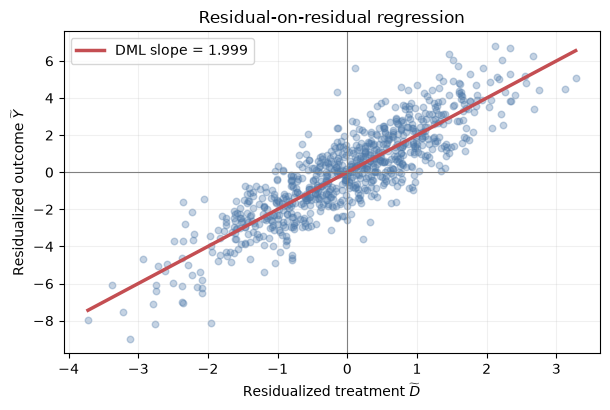

In [6]:
# Type the codes.
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.scatter(D_tilde, Y_tilde, alpha=0.32, s=22, color="#4C78A8")

grid = np.linspace(D_tilde.min(), D_tilde.max(), 100)
ax.plot(grid, theta_dml*grid, color="#C44E52", linewidth=2.5,
        label=rf"DML slope = {theta_dml:.3f}")

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set(xlabel=r"Residualized treatment $\widetilde D$",
       ylabel=r"Residualized outcome $\widetilde Y$",
       title="Residual-on-residual regression")
ax.legend()
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

### What the code accomplished

1. Machine learning estimated $h_0(X)$ and $d_0(X)$.
2. Cross-fitting ensured that observation $i$ did not train the models producing its own predictions.
3. Orthogonalization removed the variation in $Y$ and $D$ explained by $X$.
4. The final regression used $\widetilde Y$ and $\widetilde D$ to estimate $\theta_0$.

> **Key point:** DML learns $\eta_0=(h_0,d_0)$, not $g_0$ directly.


## Exercise - DML with gradient boosting

The DGP below creates nonlinear confounding with

$$
\theta_0=1.5.
$$

Use five-fold cross-fitting and gradient boosting to estimate the nuisance functions,
then calculate the residual-on-residual DML estimate.


### Exercise DGP


In [7]:
# Copy and paste the DGP from Quizzes '(Sep28) Exercise'.
rng_ex = np.random.default_rng(7)
n_ex = 600
X_ex = rng_ex.normal(size=(n_ex, 3))
theta_ex_true = 1.5

d_ex = (0.9*X_ex[:, 0] + 0.6*np.sin(X_ex[:, 1])
    - 0.4*X_ex[:, 2]**2)
g_ex = 1.2*d_ex + 0.7*X_ex[:, 0]*X_ex[:, 1] + 0.5*X_ex[:, 2]

D_ex = d_ex + rng_ex.normal(size=n_ex)
Y_ex = theta_ex_true*D_ex + g_ex + rng_ex.normal(size=n_ex)

### Exercise


In [8]:
from sklearn.ensemble import GradientBoostingRegressor

n_ex = len(Y_ex)
h_ex = np.empty(n_ex)
d_ex_hat = np.empty(n_ex)

kf_ex = KFold(
    n_splits=5,
    shuffle=True,
    random_state=7
)

for train_idx, test_idx in kf_ex.split(X_ex):

    y_model = GradientBoostingRegressor(
        n_estimators=180,
        learning_rate=0.05,
        max_depth=2,
        random_state=7
    )

    d_model = GradientBoostingRegressor(
        n_estimators=180,
        learning_rate=0.05,
        max_depth=2,
        random_state=17
    )

    # Train nuisance models
    y_model.fit(X_ex[train_idx], Y_ex[train_idx])
    d_model.fit(X_ex[train_idx], D_ex[train_idx])

    # --------------------------------------------------
    # BLANK 1: Predict h(X) for the held-out fold
    # --------------------------------------------------
    h_ex[test_idx] = y_model.predict(X_ex[test_idx])
    


    # --------------------------------------------------
    # BLANK 2: Predict d(X) for the held-out fold
    # --------------------------------------------------
    d_ex_hat[test_idx] = d_model.predict(X_ex[test_idx])


# Residualize Y and D
Y_tilde_ex = Y_ex - h_ex
D_tilde_ex = D_ex - d_ex_hat


# ------------------------------------------------------
# BLANK 3: Estimate theta using residual-on-residual
# regression
# ------------------------------------------------------
theta_dml_ex = (
    np.sum(D_tilde_ex * Y_tilde_ex) / np.sum(D_tilde_ex**2)
)


# Naive regression for comparison
theta_naive_ex = LinearRegression().fit(
    D_ex.reshape(-1, 1),
    Y_ex
).coef_[0]

print(f"True theta:     {theta_ex_true:.3f}")
print(f"Naive estimate: {theta_naive_ex:.3f}")
print(f"DML estimate:   {theta_dml_ex:.3f}")

True theta:     1.500
Naive estimate: 2.209
DML estimate:   1.537


### Exercise interpretation

The naive estimate remains distorted by the common dependence of $D$ and $Y$ on $X$.
After cross-fitting and orthogonalization, the DML estimate is close to the true value
$\theta_0=1.5$. Small differences are ordinary finite-sample and nuisance-learning error.
